In [ ]:
pip install transformers datasets torch scikit-learn evaluate accelerate

In [ ]:
from transformers import BertTokenizerFast, BertForSequenceClassification

model_checkpoint = 'bert-base-uncased'

# Load the tokenizer
tokenizer = BertTokenizerFast.from_pretrained(model_checkpoint)

# Load the model with 2 labels for binary classification
model = BertForSequenceClassification.from_pretrained(model_checkpoint, num_labels=2)

print(f"Successfully loaded {model_checkpoint} model and tokenizer.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Successfully loaded bert-base-uncased model and tokenizer.


In [ ]:
from datasets import load_dataset

# Loading the dataset without trust_remote_code as it's now in parquet format
raw_datasets = load_dataset("stanfordnlp/imdb")
print("Dataset loaded successfully:")
print(raw_datasets)

Dataset loaded successfully:
DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})


In [ ]:
# Show an example from the training set only if loading was successful
if 'raw_datasets' in globals():
    print("Example record:")
    display(raw_datasets['train'][0])
else:
    print("Dataset 'raw_datasets' is not available. Please check the previous cell for errors.")

Example record:


{'text': 'I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and ordinary denizens of Stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men.<br /><br />What kills me about I AM CURIOUS-YELLOW is that 40 years ago, this was considered pornographic. Really, the sex and nudity scenes are few and far be

In [ ]:
def tokenize_function(examples):
    return tokenizer(examples['text'], padding='max_length', truncation=True, max_length=128)

# Apply tokenization
tokenized_datasets = raw_datasets.map(tokenize_function, batched=True)

# Prepare for PyTorch: remove text and rename label
tokenized_datasets = tokenized_datasets.remove_columns(['text'])
tokenized_datasets = tokenized_datasets.rename_column('label', 'labels')
tokenized_datasets.set_format('torch')

print("Tokenization complete with max_length=128.")
print(f"Column names: {tokenized_datasets['train'].column_names}")

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Tokenization complete with max_length=128.
Column names: ['labels', 'input_ids', 'token_type_ids', 'attention_mask']


In [ ]:
from torch.utils.data import DataLoader

# Create DataLoaders
batch_size = 16

train_dataloader = DataLoader(
    tokenized_datasets["train"],
    shuffle=True,
    batch_size=batch_size
)

eval_dataloader = DataLoader(
    tokenized_datasets["test"],
    batch_size=batch_size
)

print(f"DataLoaders created with batch_size={batch_size}.")

DataLoaders created with batch_size=16.


In [ ]:
from transformers import get_linear_schedule_with_warmup
from torch.optim import AdamW
import torch

# Move model to device if not already there
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
model.to(device)

# 1. Initialize AdamW optimizer with specified hyperparameters
optimizer = AdamW(
    model.parameters(),
    lr=2e-5,
    weight_decay=0.01
)

# 2. Calculate training steps
num_epochs = 3
num_training_steps = num_epochs * len(train_dataloader)
num_warmup_steps = int(0.1 * num_training_steps)

# 3. Initialize the linear warmup scheduler
lr_scheduler = get_linear_schedule_with_warmup(
    optimizer=optimizer,
    num_warmup_steps=num_warmup_steps,
    num_training_steps=num_training_steps
)

print(f"Device: {device}")
print(f"Total training steps: {num_training_steps}")
print(f"Warmup steps (10%): {num_warmup_steps}")

Device: cuda
Total training steps: 4689
Warmup steps (10%): 468


In [ ]:
import evaluate
import numpy as np
from transformers import TrainingArguments, Trainer

# Load the accuracy metric
metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return metric.compute(predictions=predictions, references=labels)

# Calculate warmup steps (10% of total)
num_training_steps = 3 * len(train_dataloader)
num_warmup_steps = int(0.1 * num_training_steps)

# Define training arguments with gradient clipping
training_args = TrainingArguments(
    output_dir="bert-imdb-trainer",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    warmup_steps=num_warmup_steps,
    max_grad_norm=1.0,  # Gradient clipping added here
    load_best_model_at_end=True,
    logging_steps=100,
    report_to="none"
)

# Initialize the Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["test"],
    compute_metrics=compute_metrics,
)

print(f"Trainer initialized with gradient clipping and {num_warmup_steps} warmup steps.")

Trainer initialized with gradient clipping and 468 warmup steps.


In [ ]:
from datasets import config
# Workaround for the torchvision.io VideoReader ImportError
config.TORCHVISION_AVAILABLE = False

# Execute the training process
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,0.308062,0.318741,0.873040
2,0.205331,0.299554,0.891920
3,0.107649,0.446032,0.890560


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

TrainOutput(global_step=4689, training_loss=0.23800013695324526, metrics={'train_runtime': 2352.9058, 'train_samples_per_second': 31.875, 'train_steps_per_second': 1.993, 'total_flos': 4933332288000000.0, 'train_loss': 0.23800013695324526, 'epoch': 3.0})

Classification Report:
              precision    recall  f1-score   support

    Negative       0.90      0.88      0.89     12500
    Positive       0.89      0.90      0.89     12500

    accuracy                           0.89     25000
   macro avg       0.89      0.89      0.89     25000
weighted avg       0.89      0.89      0.89     25000



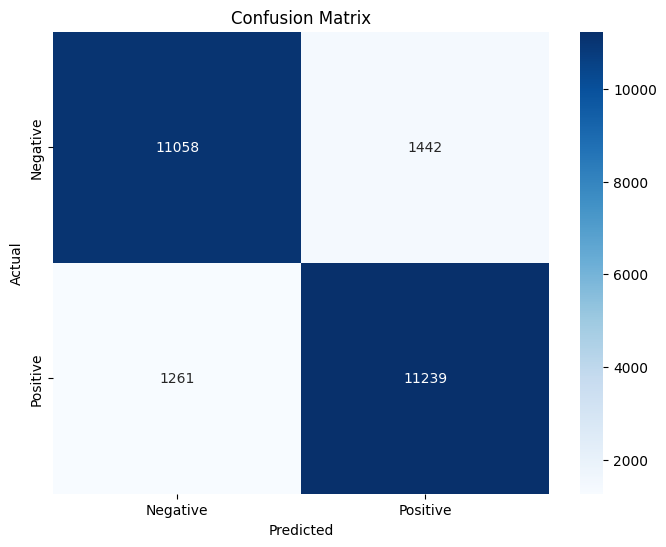

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Get predictions from the trainer
predictions_output = trainer.predict(tokenized_datasets['test'])
predictions = np.argmax(predictions_output.predictions, axis=-1)
labels = predictions_output.label_ids

# 1. Print Accuracy and F1 (Compute Metrics already handled these, but let's show class-wise details)
print("Classification Report:")
print(classification_report(labels, predictions, target_names=['Negative', 'Positive']))

# 2. Plot Confusion Matrix
cm = confusion_matrix(labels, predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
def predict(text):
    """
    Tokenizes input text, performs a forward pass through the model,
    and returns the predicted sentiment label.
    """
    # 1. Tokenize the input text
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=128
    ).to(device)

    # 2. Model forward pass
    model.eval()
    with torch.no_grad():
        outputs = model(**inputs)

    # 3. Get prediction (argmax on logits)
    logits = outputs.logits
    prediction = torch.argmax(logits, dim=-1).item()

    # Map 0 -> Negative, 1 -> Positive
    return "Positive" if prediction == 1 else "Negative"

# --- Demo on Custom Reviews ---
test_reviews = [
    "I absolutely loved this movie! The acting was top-notch and the plot was gripping from start to finish.",
    "What a waste of time. The script was poorly written and the characters were uninteresting.",
    "It was okay, but I wouldn't watch it again. Some parts were slow, though the ending was decent.",
    "A cinematic masterpiece that redefines the genre. Truly breathtaking.",
    "I disliked every bit of the acting."
]

print(f"--- Custom Inference Demo ---\n")
for review in test_reviews:
    label = predict(review)
    print(f"Review: {review}")
    print(f"Result: {label}\n")

--- Custom Inference Demo ---

Review: I absolutely loved this movie! The acting was top-notch and the plot was gripping from start to finish.
Result: Positive

Review: What a waste of time. The script was poorly written and the characters were uninteresting.
Result: Negative

Review: It was okay, but I wouldn't watch it again. Some parts were slow, though the ending was decent.
Result: Negative

Review: A cinematic masterpiece that redefines the genre. Truly breathtaking.
Result: Positive

Review: I disliked every bit of the acting.
Result: Negative

